In [67]:
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import mne
import tensorflow as tf
from scipy.stats import mannwhitneyu
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, roc_auc_score, roc_curve, auc, classification_report

In [2]:
ROOT_DIR = os.getcwd()
DATA_DIR = os.path.join(ROOT_DIR, "..", "data")
RESULTS_DIR = os.path.join(ROOT_DIR, "..", "results")
meta = pd.read_csv(os.path.join(DATA_DIR, "participants.tsv"), sep="\t")

In [3]:
meta.head()

,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22


EEGNet AD vs. CN classification

In [4]:
# Load results from EEGNet AD vs CN classification
file_path = "EEGNet_A_C/C_A/all_results.pkl"

with open(os.path.join(RESULTS_DIR, file_path), "rb") as f:
    eegnet_ad = pickle.load(f)

In [5]:
# Check keys in results
eegnet_ad.keys()

dict_keys(['meta_data', 'outer_folds', 'subject_metadata'])

In [7]:
# Check first outer fold
eegnet_ad["outer_folds"][0]

{'outer_fold': 1,
 'test_subject_id': 'sub-001',
 'best_trial_number': 10,
 'best_params': {'F1': 14,
  'D': 1,
  'dropoutRate': 0.25,
  'kernLength': 64,
  'dropoutType': 'Dropout',
  'learning_rate': 6.89927726469809e-05,
  'optimizer': 'adam',
  'batch_size': 128},
 'best_epochs': 4,
 'trained_epochs': 16,
 'inner_model_filepath': '/home/u961155/thesis_codes/results/EEGNet_A_C/C_A/best_model_outer_fold_1.keras',
 'val_loss': 0.6062037944793701,
 'val_accuracy': 0.7338481545448303,
 'test_accuracy': 1.0,
 'true_labels': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 

In [8]:
# Check fold metadata
eegnet_ad["meta_data"]

{'model_name': 'EEGNet_A_C',
 'class_names': ['C', 'A'],
 'label_map': {'A': 1, 'C': 0},
 'epoch_duration': 4,
 'sampling_rate': 128,
 'chans': 19,
 'samples': 512}

In [9]:
# Check the number of saved folds
print(len(eegnet_ad["outer_folds"]))

65


In [10]:
# Check keys in outer folds
eegnet_ad["outer_folds"][0].keys()

dict_keys(['outer_fold', 'test_subject_id', 'best_trial_number', 'best_params', 'best_epochs', 'trained_epochs', 'inner_model_filepath', 'val_loss', 'val_accuracy', 'test_accuracy', 'true_labels', 'pred_probs', 'pred_labels'])

In [11]:
# Check fold results
for fold in eegnet_ad["outer_folds"]:
    print(fold["outer_fold"], fold["test_subject_id"], fold["test_accuracy"])

1 sub-001 1.0
2 sub-002 0.25316455696202533
3 sub-003 0.7368421052631579
4 sub-004 1.0
5 sub-005 0.9875311720698254
6 sub-006 0.09841269841269841
7 sub-007 1.0
8 sub-008 0.9746835443037974
9 sub-009 0.40327868852459015
10 sub-010 0.514866979655712
11 sub-011 0.4490861618798956
12 sub-012 0.37727272727272726
13 sub-013 0.9401913875598086
14 sub-014 0.9527896995708155
15 sub-015 0.49443207126948774
16 sub-016 0.9876288659793815
17 sub-017 1.0
18 sub-018 1.0
19 sub-019 0.7467248908296943
20 sub-020 0.9838337182448037
21 sub-021 0.25925925925925924
22 sub-022 0.9951100244498777
23 sub-023 0.9375
24 sub-024 1.0
25 sub-025 0.04105571847507331
26 sub-026 1.0
27 sub-027 1.0
28 sub-028 1.0
29 sub-029 1.0
30 sub-030 1.0
31 sub-031 0.4059233449477352
32 sub-032 0.9445843828715366
33 sub-033 0.9943019943019943
34 sub-034 0.9958592132505176
35 sub-035 1.0
36 sub-036 0.3126491646778043
37 sub-037 0.6640826873385013
38 sub-038 0.7454954954954955
39 sub-039 0.8160377358490566
40 sub-040 0.844074844074

In [12]:
# Check one specific fold 
fold_idx = 0
fold = eegnet_ad["outer_folds"][fold_idx]

y_true = fold["true_labels"]
y_pred = fold["pred_labels"]
y_prob = fold["pred_probs"]

print("True labels:", y_true[:10])
print("Predicted labels:", y_pred[:10])
print("Predicted probabilities:", y_prob[:10])

True labels: [1 1 1 1 1 1 1 1 1 1]
Predicted labels: [1 1 1 1 1 1 1 1 1 1]
Predicted probabilities: [0.6815293  0.6920767  0.69437766 0.6809404  0.718216   0.73593575
 0.71233547 0.72508967 0.7563343  0.7186408 ]


In [13]:
# Append subject metadata to results
eegnet_ad["subject_metadata"] = {}

for fold in eegnet_ad["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        # print(subject_id)
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        eegnet_ad["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }

In [14]:
# Check updated metadata
eegnet_ad["subject_metadata"]["sub-001"]

{'gender': 'F', 'age': np.int64(57), 'group': 'A'}

In [16]:
# Get the parameters of the best model based on validation accuracy
df_val_eegnet_ad = pd.DataFrame(eegnet_ad["outer_folds"])
best_row = df_val_eegnet_ad.loc[df_val_eegnet_ad["val_accuracy"].idxmax()]["best_params"]
best_model_path = df_val_eegnet_ad.loc[df_val_eegnet_ad["val_accuracy"].idxmax()]["inner_model_filepath"]
for key, value in best_row.items():
    print(f"{key}: {value}")
print(best_model_path)

F1: 13
D: 1
dropoutRate: 0.25
kernLength: 64
dropoutType: Dropout
learning_rate: 5.8195897760382745e-05
optimizer: adam
batch_size: 64
/home/u961155/thesis_codes/results/EEGNet_A_C/C_A/best_model_outer_fold_21.keras


In [20]:
# Compile test accuracies by subject
test_accuracies = []

for fold in eegnet_ad["outer_folds"]:
    acc = fold["test_accuracy"]
    subject_id = fold["test_subject_id"]
    metadata = eegnet_ad["subject_metadata"][subject_id]

    test_accuracies.append({
        "test_subject_id": subject_id,
        "test_accuracy": acc,
        "subject_group": metadata["group"],
        "gender": metadata["gender"]
    })

acc_eegnet_ad = pd.DataFrame(test_accuracies)
acc_eegnet_ad.head()

,test_subject_id,test_accuracy,subject_group,gender
0,sub-001,1.000000,A,F
1,sub-002,0.253165,A,F
2,sub-003,0.736842,A,M
3,sub-004,1.000000,A,F
4,sub-005,0.987531,A,M


In [44]:
# Overall mean and std of test accuracies
print(acc_eegnet_ad["test_accuracy"].mean(), acc_eegnet_ad["test_accuracy"].std())

0.7068570434091808 0.3162519917755785


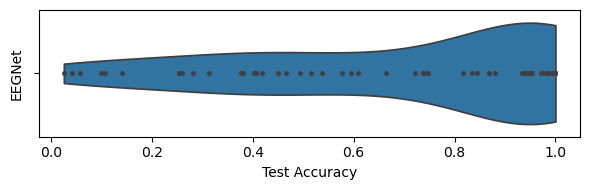

In [45]:
# Violin plot of test accuracies
plt.figure(figsize=(6, 2)) 
sns.violinplot(data=acc_eegnet_ad, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("EEGNet")
plt.tight_layout()
plt.savefig("figures/EEGNet_AD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
# Summary statistics of test accuracies by group
acc_eegnet_ad.groupby("subject_group")["test_accuracy"].describe()

,count,mean,std,min,25%,50%,75%,max
subject_group,,,,,,,,
A,36.0,0.771861,0.315158,0.041056,0.483096,0.979259,1.00000,1.000000
C,29.0,0.626163,0.303767,0.025510,0.418552,0.720982,0.86802,0.985816


In [47]:
# Summary statistics of test accuracies by gender
acc_eegnet_ad.groupby("gender")["test_accuracy"].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
F,35.0,0.729293,0.341676,0.041056,0.404601,0.940191,1.000000,1.0
M,30.0,0.680682,0.287291,0.025510,0.499541,0.736971,0.945848,1.0


In [48]:
# Count of subjects by gender
acc_eegnet_ad["gender"].value_counts()

gender
F    35
M    30
Name: count, dtype: int64

In [126]:
# Statistical test: the Mann-Whitney U rank test between males and females
acc_m = acc_eegnet_ad[acc_eegnet_ad["gender"] == "M"]["test_accuracy"]
acc_f = acc_eegnet_ad[acc_eegnet_ad["gender"] == "F"]["test_accuracy"]
stat, p = mannwhitneyu(acc_m, acc_f, alternative="two-sided")
print(f"U = {stat:.4f}, p = {p:.4f}")

U = 399.5000, p = 0.0989


In [127]:
# Statistical test: the Mann-Whitney U rank test between AD and CN groups
acc_ad = acc_eegnet_ad[acc_eegnet_ad["subject_group"] == "A"]["test_accuracy"]
acc_cn = acc_eegnet_ad[acc_eegnet_ad["subject_group"] == "C"]["test_accuracy"]

stat, p = mannwhitneyu(acc_ad, acc_cn, alternative="two-sided")
print(f"U = {stat:.4f}, p = {p:.4f}")

U = 745.0000, p = 0.0032


C:\Users\xiaox\AppData\Local\Temp\ipykernel_25484\1777068677.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=acc_eegnet_ad, x="gender", y="test_accuracy", order=["M", "F"], palette="pastel", width=0.5)


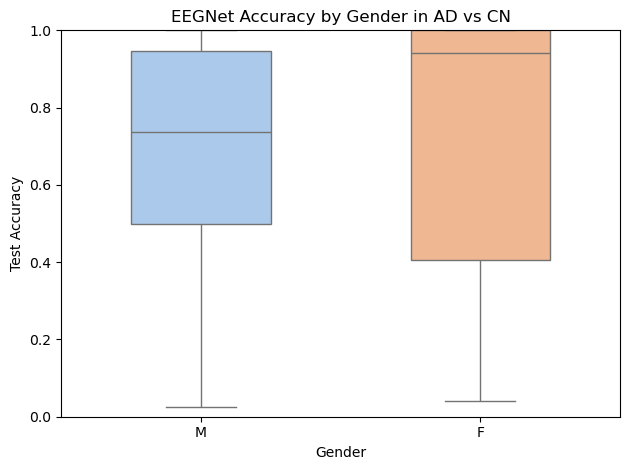

In [137]:
# Boxplot of EEGNet test accuracies by gender
sns.boxplot(data=acc_eegnet_ad, x="gender", y="test_accuracy", order=["M", "F"], palette="pastel", width=0.5)
plt.ylim(0, 1)
plt.xlabel("Gender")
plt.ylabel("Test Accuracy")
plt.title("EEGNet Accuracy by Gender in AD vs CN")
plt.tight_layout()
plt.savefig("eegnet_ad_gender_boxplot.png", dpi=300)
plt.show()

In [52]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in eegnet_ad["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [53]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred, pos_label=1)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.7071552439116339
F1 Score: 0.7416522548889185
Sensitivity: 0.7682237839327546
Specificity: 0.6333666333666333
ROC AUC: 0.8171267521463883
Confusion Matrix:
 [[ 7608  4404]
 [ 3364 11150]]


In [54]:
print(classification_report(all_y_true, all_y_pred, target_names=["CN", "AD"]))

              precision    recall  f1-score   support

          CN       0.69      0.63      0.66     12012
          AD       0.72      0.77      0.74     14514

    accuracy                           0.71     26526
   macro avg       0.71      0.70      0.70     26526
weighted avg       0.71      0.71      0.71     26526



In [55]:
# Subject-level predictions and true labels
rows = []

for fold in eegnet_ad["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]

    # Majority vote for subject-level prediction
    pred_majority = np.bincount(y_pred).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

subjects_eegnet_ad = pd.DataFrame(rows)

In [56]:
subjects_eegnet_ad.head()

,subject_id,true_label,pred_label
0,sub-001,1,1
1,sub-002,1,0
2,sub-003,1,1
3,sub-004,1,1
4,sub-005,1,1


In [57]:
cm_subjects = confusion_matrix(subjects_eegnet_ad["true_label"], subjects_eegnet_ad["pred_label"])
print("Subject-level Confusion Matrix:\n", cm_subjects)

Subject-level Confusion Matrix:
 [[20  9]
 [10 26]]


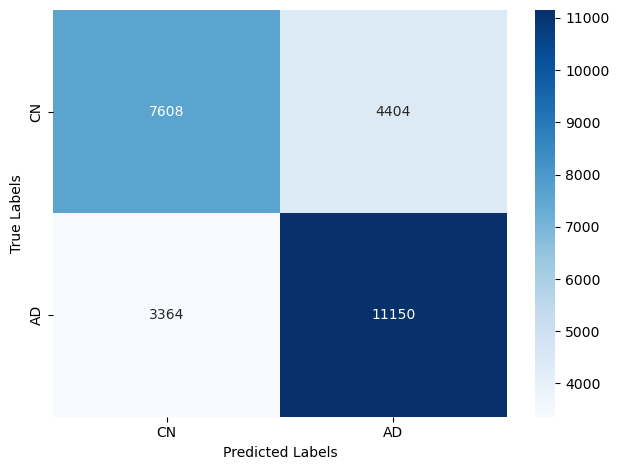

In [59]:
# Plot sample-level confusion matrix
class_names = ["CN", "AD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/EEGNet_AD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

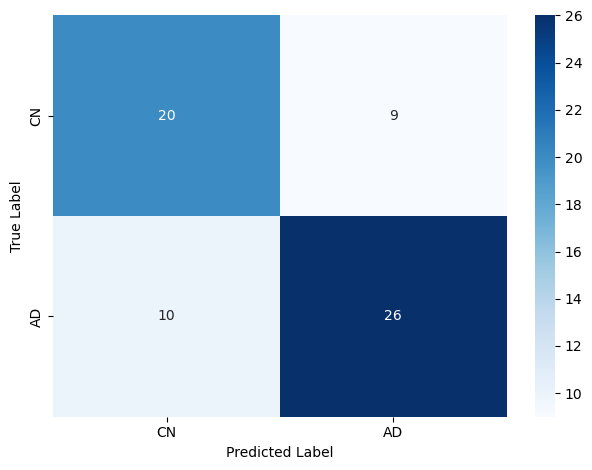

In [60]:
# Plot subject-level confusion matrix
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/EEGNet_AD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

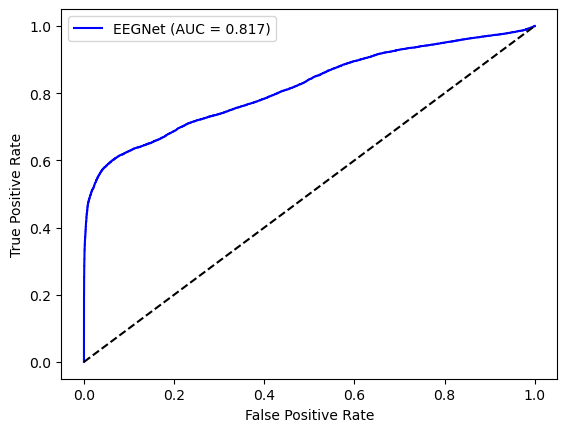

In [61]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"EEGNet (AUC = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/EEGNet_AD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [62]:
# Load the best model
best_model_eeg_ad = tf.keras.models.load_model(os.path.join(RESULTS_DIR, "EEGNet_A_C/C_A/best_model_outer_fold_21.keras"))

In [68]:
# Get model summary
best_model_eeg_ad.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 19, 512, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 19, 512, 13)    │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 19, 512, 13)    │            52 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 512, 13)     │           247 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 512, 13)     │            52 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 512, 13)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 128, 13)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128, 13)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 128, 13)     │           377 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 128, 13)     │            52 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 128, 13)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 16, 13)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 16, 13)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 208)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           209 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sigmoid (Activation)            │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,309 (20.74 KB)

 Trainable params: 1,743 (6.81 KB)

 Non-trainable params: 78 (312.00 B)

 Optimizer params: 3,488 (13.63 KB)

In [104]:
# Find the depthwise conv layer (spatial filtering)
for layer in best_model_eeg_ad.layers:
    if "depthwise_conv2d" in layer.name:
        depthwise_layer = layer
        break

# Get weights in the depthwise conv layer
weights = depthwise_layer.get_weights()[0]
print(weights.shape)
weights = weights.squeeze()
print(weights.shape)

(19, 1, 13, 1)
(19, 13)


(<matplotlib.image.AxesImage at 0x2667c210690>,
 <matplotlib.contour.QuadContourSet at 0x2667c2107d0>)

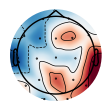

In [106]:
# Load the data of the first subject (001)
data_folder = os.path.join(ROOT_DIR, "..", "data")
file_path = "derivatives/sub-001/eeg/sub-001_task-eyesclosed_eeg.set"
raw_001 = mne.io.read_raw_eeglab(
    os.path.join(
        data_folder,
        file_path
    ),
    preload=True
)
info = raw_001.info # get info for channel locations

# Plot topomap of the first filter weights
mne.viz.plot_topomap(weights[:, 0], pos=info, show=False)

EEGNet FTD vs. CN classification

In [109]:
# Load results from EEGNet FTD vs CN classification
with open(os.path.join(RESULTS_DIR, "EEGNet_F_C/C_F/all_results.pkl"), "rb") as f:
    eegnet_ftd = pickle.load(f)

In [110]:
# Check fold metadata
eegnet_ftd["meta_data"]

{'model_name': 'EEGNet_F_C',
 'class_names': ['C', 'F'],
 'label_map': {'F': 1, 'C': 0},
 'epoch_duration': 4,
 'sampling_rate': 128,
 'chans': 19,
 'samples': 512}

In [112]:
# Check the number of saved folds
print(len(eegnet_ftd["outer_folds"]))

52


In [113]:
# Append subject metadata to results
eegnet_ftd["subject_metadata"] = {}

for fold in eegnet_ftd["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        eegnet_ftd["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }

In [114]:
# Check updated metadata
eegnet_ftd["subject_metadata"]["sub-060"]

{'gender': 'F', 'age': np.int64(71), 'group': 'C'}

In [115]:
# Get the parameters of the best model based on validation accuracy
df_val_eegnet_ftd = pd.DataFrame(eegnet_ftd["outer_folds"])
best_row = df_val_eegnet_ftd.loc[df_val_eegnet_ftd["val_accuracy"].idxmax()]["best_params"]
best_model_path = df_val_eegnet_ftd.loc[df_val_eegnet_ftd["val_accuracy"].idxmax()]["inner_model_filepath"]
for key, value in best_row.items():
    print(f"{key}: {value}")
print(best_model_path)

F1: 13
D: 1
dropoutRate: 0.25
kernLength: 64
dropoutType: Dropout
learning_rate: 5.7051802094492746e-05
optimizer: adam
batch_size: 128
/home/u961155/thesis_codes/results/EEGNet_F_C/C_F/best_model_outer_fold_34.keras


In [116]:
# Compile test accuracies by subject
test_accuracies = []

for fold in eegnet_ftd["outer_folds"]:
    acc = fold["test_accuracy"]
    subject_id = fold["test_subject_id"]
    metadata = eegnet_ftd["subject_metadata"][subject_id]

    test_accuracies.append({
        "test_subject_id": subject_id,
        "test_accuracy": acc,
        "subject_group": metadata["group"],
        "gender": metadata["gender"]
    })

acc_eegnet_ftd = pd.DataFrame(test_accuracies)
acc_eegnet_ftd.head()

,test_subject_id,test_accuracy,subject_group,gender
0,sub-037,1.000000,C,M
1,sub-038,0.693694,C,M
2,sub-039,0.924528,C,M
3,sub-040,0.785863,C,M
4,sub-041,0.936652,C,F


In [117]:
# Overall mean and std of test accuracies
print(acc_eegnet_ftd["test_accuracy"].mean(), acc_eegnet_ftd["test_accuracy"].std())

0.6691228535221766 0.35736405613226463


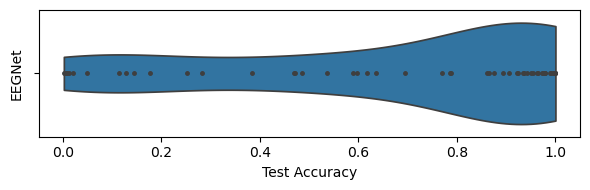

In [119]:
# Violin plot of test accuracies
plt.figure(figsize=(6, 2))
sns.violinplot(data=acc_eegnet_ftd, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("EEGNet")
plt.tight_layout()
plt.savefig("figures/EEGNet_FTD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [120]:
# Summary statistics of test accuracies by group
acc_eegnet_ftd.groupby("subject_group")["test_accuracy"].describe()

,count,mean,std,min,25%,50%,75%,max
subject_group,,,,,,,,
C,29.0,0.729946,0.312239,0.011792,0.597855,0.874384,0.964583,1.0
F,23.0,0.592433,0.401180,0.002193,0.136166,0.770000,0.967399,1.0


In [121]:
# Summary statistics of test accuracies by gender
acc_eegnet_ftd.groupby("gender")["test_accuracy"].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
F,20.0,0.653508,0.394720,0.002193,0.398390,0.907355,0.964933,1.0
M,32.0,0.678882,0.338162,0.007353,0.447386,0.824345,0.968132,1.0


In [123]:
# Count of subjects
acc_eegnet_ftd["gender"].value_counts()

gender
M    32
F    20
Name: count, dtype: int64

In [128]:
# Statistical test: the Mann-Whitney U rank test between males and females
acc_m = acc_eegnet_ftd[acc_eegnet_ftd["gender"] == "M"]["test_accuracy"]
acc_f = acc_eegnet_ftd[acc_eegnet_ftd["gender"] == "F"]["test_accuracy"]
stat, p = mannwhitneyu(acc_m, acc_f, alternative="two-sided")
print(f"U = {stat:.4f}, p = {p:.4f}")

U = 324.0000, p = 0.9475


In [129]:
# Statistical test: the Mann-Whitney U rank test between FTD and CN groups
acc_ftd = acc_eegnet_ftd[acc_eegnet_ftd["subject_group"] == "F"]["test_accuracy"]
acc_cn = acc_eegnet_ftd[acc_eegnet_ftd["subject_group"] == "C"]["test_accuracy"]
stat, p = mannwhitneyu(acc_ftd, acc_cn, alternative="two-sided")
print(f"U = {stat:.4f}, p = {p:.4f}")

U = 280.5000, p = 0.3330


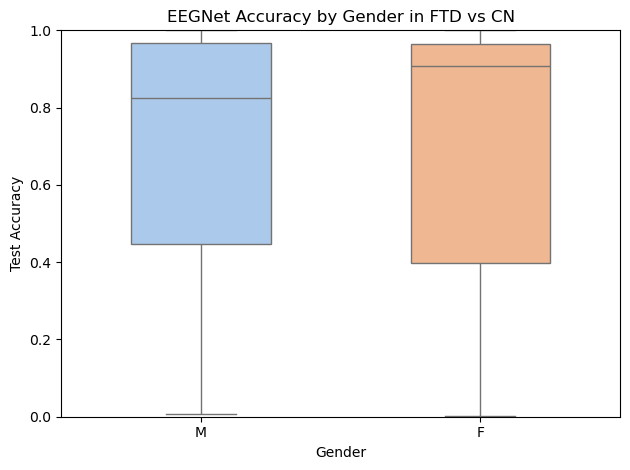

In [134]:
# Boxplot of EEGNet test accuracies distribution by gender
sns.boxplot(data=acc_eegnet_ftd, x="gender", y="test_accuracy", hue="gender", order=["M", "F"], palette="pastel", width=0.5)
plt.ylim(0, 1)
plt.xlabel("Gender")
plt.ylabel("Test Accuracy")
plt.title("EEGNet Accuracy by Gender in FTD vs CN")
plt.tight_layout()
plt.savefig("eegnet_ftd_gender_boxplot.png", dpi=300)
plt.show()

In [138]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in eegnet_ftd["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [140]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred, pos_label=1)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.6754463845319127
F1 Score: 0.5994643291940589
Sensitivity: 0.5959816025175503
Specificity: 0.7301032301032301
ROC AUC: 0.7004532323159773
Confusion Matrix:
 [[8770 3242]
 [3338 4924]]


In [139]:
# Get classification report
print(classification_report(all_y_true, all_y_pred, target_names=["CN", "FTD"]))

              precision    recall  f1-score   support

          CN       0.72      0.73      0.73     12012
         FTD       0.60      0.60      0.60      8262

    accuracy                           0.68     20274
   macro avg       0.66      0.66      0.66     20274
weighted avg       0.67      0.68      0.68     20274



In [142]:
# Subject-level predictions and true labels
rows = []

for fold in eegnet_ftd["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]

    # Majority vote for subject-level prediction
    pred_majority = np.bincount(y_pred).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

subjects_eegnet_ftd = pd.DataFrame(rows)
subjects_eegnet_ftd.head()

,subject_id,true_label,pred_label
0,sub-037,0,0
1,sub-038,0,0
2,sub-039,0,0
3,sub-040,0,0
4,sub-041,0,0


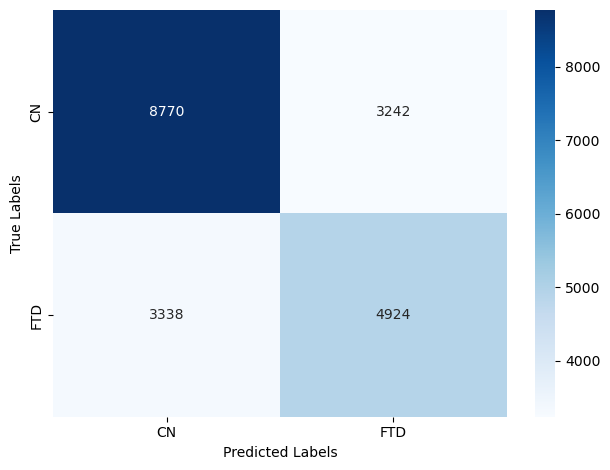

In [143]:
# Plot sample-level confusion matrix
class_names = ["CN", "FTD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/EEGNet_FTD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

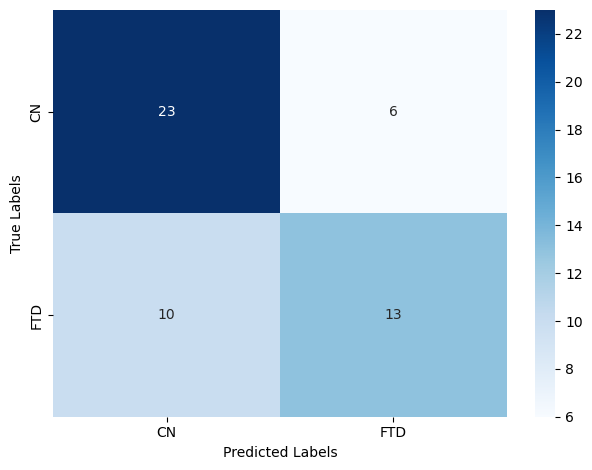

In [144]:
# Plot subject-level confusion matrix
cm_subjects = confusion_matrix(subjects_eegnet_ftd["true_label"], subjects_eegnet_ftd["pred_label"])
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/EEGNet_FTD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

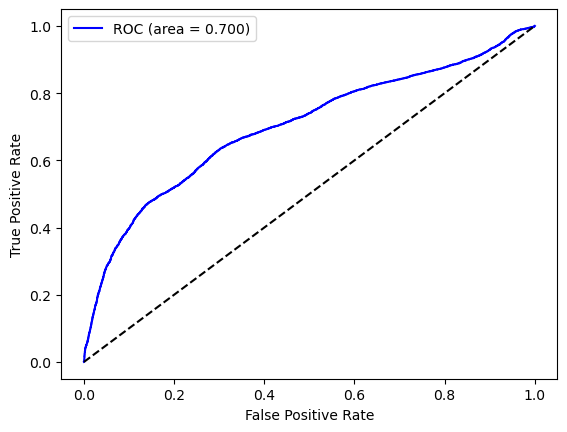

In [145]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/EEGNet_FTD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

Customised CNN AD vs. CN classification

In [146]:
# Load results from CNN AD vs CN classification
with open(os.path.join(RESULTS_DIR, "OptunaCNN/alpha/C_A/all_results.pkl"), "rb") as f:
    cnn_ad = pickle.load(f)

In [147]:
# Check fold metadata
cnn_ad["meta_data"]

{'model_name': 'OptunaCNN',
 'class_names': ['C', 'A'],
 'label_map': {'A': 1, 'C': 0},
 'band': 'alpha'}

In [148]:
# Append subject metadata to results
cnn_ad["subject_metadata"] = {}

for fold in cnn_ad["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        # print(subject_id)
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        cnn_ad["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }

In [149]:
# Check updated metadata
cnn_ad["subject_metadata"]["sub-001"]

{'gender': 'F', 'age': np.int64(57), 'group': 'A'}

In [150]:
# Get the parameters of the best model based on validation accuracy
df_val_cnn_ad = pd.DataFrame(cnn_ad["outer_folds"])
best_row = df_val_cnn_ad.loc[df_val_cnn_ad["val_accuracy"].idxmax()]["best_params"]
best_model_path = df_val_cnn_ad.loc[df_val_cnn_ad["val_accuracy"].idxmax()]["model_filepath"]
for key, value in best_row.items():
    print(f"{key}: {value}")
print(best_model_path)

optimizer: Adam
learning_rate: 0.0008867751066021209
weight_decay: 0.00013931510265314653
batch_size: 128
n_layers: 2
filters_0: 64
conv_0_activation: relu
filters_1: 96
conv_1_use_batchnorm: True
conv_1_activation: relu
n_fc_layers: 2
fc_0_out_features: 192
fc_0_use_batchnorm: False
fc_0_activation: relu
fc_0_dropout_rate: 0.4466496010922328
fc_1_out_features: 64
fc_1_use_batchnorm: False
fc_1_activation: relu
fc_1_dropout_rate: 0.30073467035373463
/home/u961155/thesis_codes/results/OptunaCNN/alpha/_RBPC_A/best_model_outer_fold_18.pt


In [151]:
# Compile test accuracies by subject
test_accuracies = []

for fold in cnn_ad["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc
    })

acc_cnn_ad = pd.DataFrame(test_accuracies)
acc_cnn_ad.head()

,test_subject_id,test_accuracy
0,sub-001,1.000000
1,sub-002,0.487342
2,sub-003,0.313531
3,sub-004,1.000000
4,sub-005,0.980025


In [152]:
print(acc_cnn_ad["test_accuracy"].mean(), acc_cnn_ad["test_accuracy"].std())

0.6614678264237367 0.29207810847951804


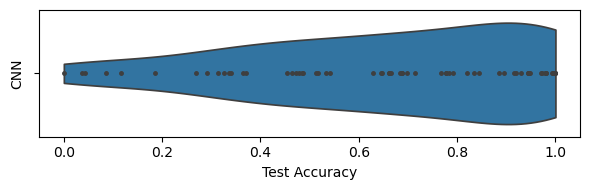

In [153]:
# Violin plot of test accuracies
plt.figure(figsize=(6, 2))
sns.violinplot(data=acc_cnn_ad, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("CNN")
plt.tight_layout()
plt.savefig("figures/CNN_AD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [154]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in cnn_ad["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [155]:
print(classification_report(all_y_true, all_y_pred, target_names=["CN", "AD"]))

              precision    recall  f1-score   support

          CN       0.64      0.58      0.61     24011
          AD       0.68      0.73      0.70     29009

    accuracy                           0.66     53020
   macro avg       0.66      0.66      0.66     53020
weighted avg       0.66      0.66      0.66     53020



In [156]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred, pos_label=1)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.6627121840814787
F1 Score: 0.7034672591904754
Sensitivity: 0.7312213450997966
Specificity: 0.5799425263420932
ROC AUC: 0.7169525788678166
Confusion Matrix:
 [[13925 10086]
 [ 7797 21212]]


In [158]:
# Subject-level predictions and true labels
rows = []

for fold in cnn_ad["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]
    pred_majority = np.bincount(y_pred.astype(int)).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

subjects_cnn_ad = pd.DataFrame(rows)
subjects_cnn_ad.head()

,subject_id,true_label,pred_label
0,sub-001,1.0,1
1,sub-002,1.0,0
2,sub-003,1.0,0
3,sub-004,1.0,1
4,sub-005,1.0,1


In [159]:
cm_subjects = confusion_matrix(subjects_cnn_ad["true_label"], subjects_cnn_ad["pred_label"])
print("Subject-level Confusion Matrix:\n", cm_subjects)

Subject-level Confusion Matrix:
 [[18 11]
 [ 9 27]]


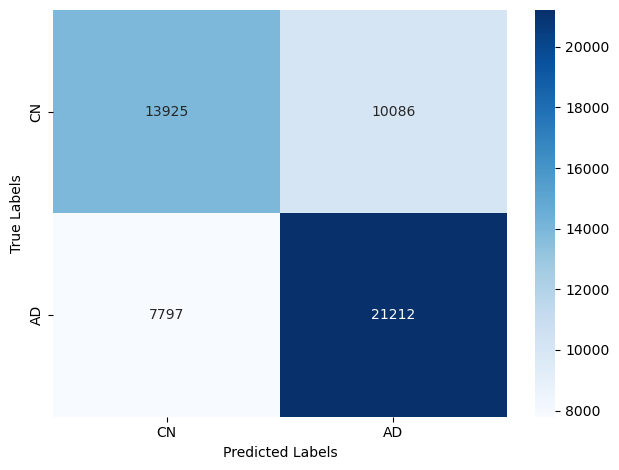

In [160]:
# Plot sample-level confusion matrix
class_names = ["CN", "AD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/CNN_AD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

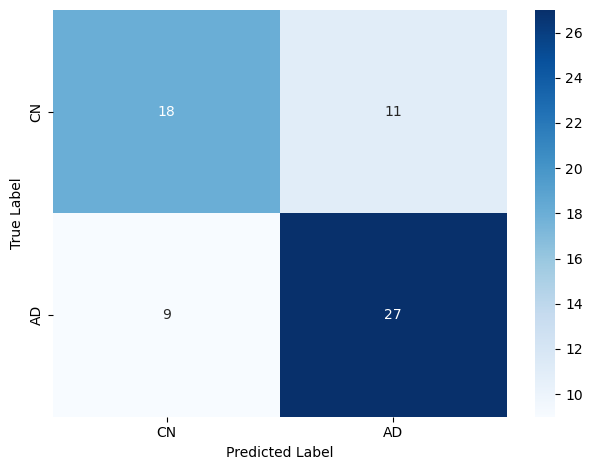

In [161]:
# Plot subject-level confusion matrix
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/CNN_AD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

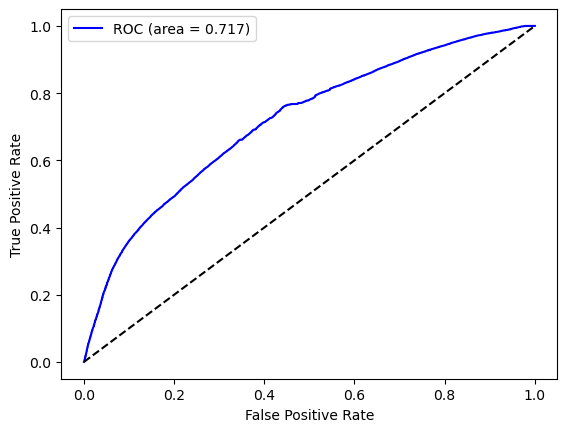

In [162]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/CNN_AD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

Customised CNN FTD vs. CN classification

In [163]:
# Load results from CNN FTD vs CN classification
with open(os.path.join(RESULTS_DIR, "OptunaCNN/alpha/C_F/all_results.pkl"), "rb") as f:
    cnn_ftd = pickle.load(f)

In [164]:
# Check fold metadata
cnn_ftd["meta_data"]

{'model_name': 'OptunaCNN',
 'class_names': ['C', 'F'],
 'label_map': {'F': 1, 'C': 0},
 'band': 'alpha'}

In [165]:
# Append subject metadata to results
cnn_ftd["subject_metadata"] = {}

for fold in cnn_ftd["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        # print(subject_id)
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        cnn_ftd["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }

In [166]:
# Check updated metadata
cnn_ftd["subject_metadata"]["sub-060"]

{'gender': 'F', 'age': np.int64(71), 'group': 'C'}

In [167]:
# Get the parameters of the best model based on validation accuracy
df_val_eegnet_ftd = pd.DataFrame(cnn_ftd["outer_folds"])
best_row = df_val_eegnet_ftd.loc[df_val_eegnet_ftd["val_accuracy"].idxmax()]["best_params"]
best_model_path = df_val_eegnet_ftd.loc[df_val_eegnet_ftd["val_accuracy"].idxmax()]["model_filepath"]
for key, value in best_row.items():
    print(f"{key}: {value}")
print(best_model_path)

optimizer: Adam
learning_rate: 0.0006034063988274968
weight_decay: 0.00012917303598091826
batch_size: 128
n_layers: 2
filters_0: 64
conv_0_activation: relu
filters_1: 96
conv_1_use_batchnorm: True
conv_1_activation: relu
n_fc_layers: 2
fc_0_out_features: 192
fc_0_use_batchnorm: False
fc_0_activation: relu
fc_0_dropout_rate: 0.3841189266671815
fc_1_out_features: 64
fc_1_use_batchnorm: False
fc_1_activation: relu
fc_1_dropout_rate: 0.13783723561372205
/home/u961155/thesis_codes/results/OptunaCNN/alpha/rbpC_F/best_model_outer_fold_38.pt


In [168]:
# Compile test accuracies by subject
test_accuracies = []

for fold in cnn_ftd["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc
    })

acc_cnn_ftd = pd.DataFrame(test_accuracies)
acc_cnn_ftd.head()

,test_subject_id,test_accuracy
0,sub-037,0.954780
1,sub-038,0.432432
2,sub-039,0.958678
3,sub-040,0.623701
4,sub-041,0.227633


In [170]:
print(acc_cnn_ftd["test_accuracy"].mean(), acc_cnn_ftd["test_accuracy"].std())

0.5166237188521057 0.3412785257894965


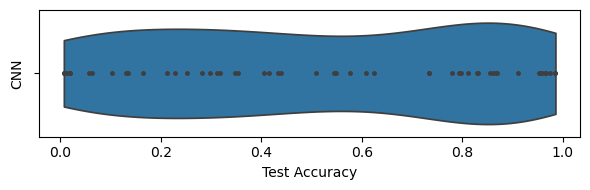

In [171]:
# Violing plot of test accuracies
plt.figure(figsize=(6, 2))
sns.violinplot(data=acc_cnn_ftd, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("CNN")
plt.tight_layout()
plt.savefig("figures/CNN_FTD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [172]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in cnn_ftd["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [173]:
print(classification_report(all_y_true, all_y_pred, target_names=["CN", "FTD"]))

              precision    recall  f1-score   support

          CN       0.59      0.63      0.61     24011
         FTD       0.41      0.37      0.39     16510

    accuracy                           0.53     40521
   macro avg       0.50      0.50      0.50     40521
weighted avg       0.52      0.53      0.52     40521



In [174]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred, pos_label=1)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.5251597936872239
F1 Score: 0.3861932561329633
Sensitivity: 0.366626287098728
Specificity: 0.6341676731498064
ROC AUC: 0.5274510640325587
Confusion Matrix:
 [[15227  8784]
 [10457  6053]]


In [176]:
# Subject-level predictions and true labels
rows = []

for fold in cnn_ftd["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]
    pred_majority = np.bincount(y_pred.astype(int)).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

subjects_cnn_ftd = pd.DataFrame(rows)
subjects_cnn_ftd.head()

,subject_id,true_label,pred_label
0,sub-037,0.0,0
1,sub-038,0.0,1
2,sub-039,0.0,0
3,sub-040,0.0,0
4,sub-041,0.0,1


In [177]:
cm_subjects = confusion_matrix(subjects_cnn_ftd["true_label"], subjects_cnn_ftd["pred_label"])
print("Subject-level Confusion Matrix:\n", cm_subjects)

Subject-level Confusion Matrix:
 [[20  9]
 [16  7]]


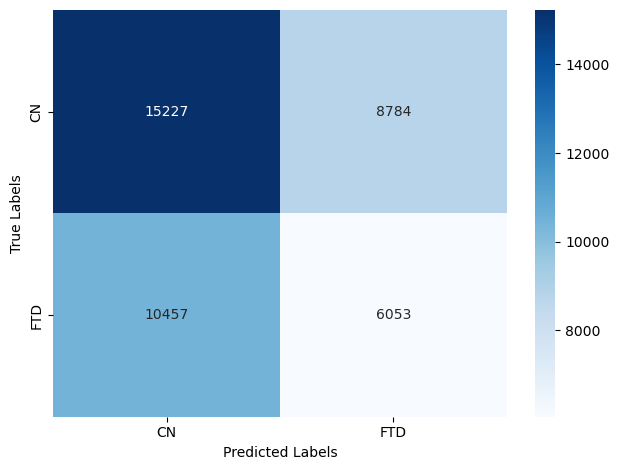

In [178]:
# Plot sample-level confusion matrix
class_names = ["CN", "FTD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/CNN_FTD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

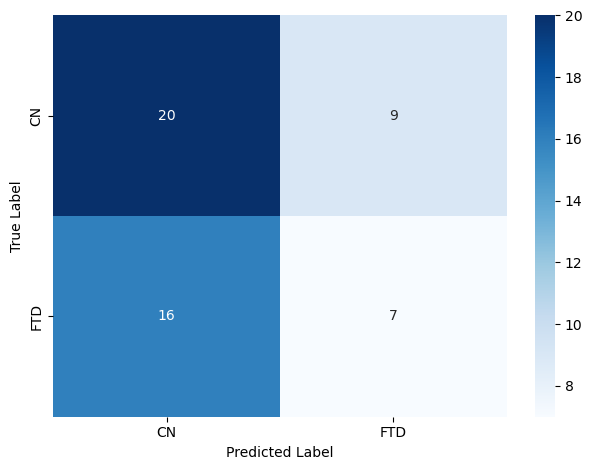

In [179]:
# Plot subject-level confusion matrix
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/CNN_FTD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

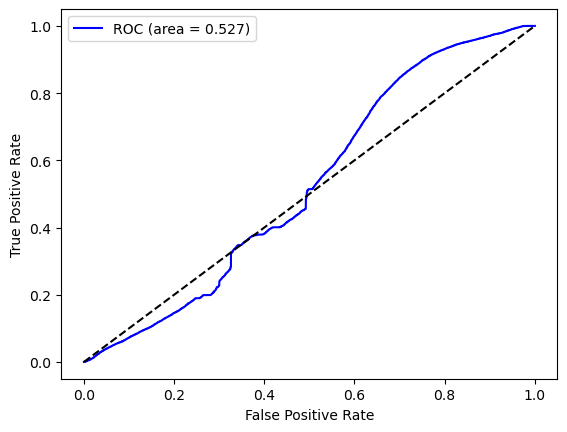

In [180]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/CNN_FTD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

AlexNet AD vs. CN classification

In [181]:
# Load results from EEGNet FTD vs CN classification
with open(os.path.join(RESULTS_DIR, "PretrainedAlexNet/alpha/C_A/final_complete_all_folds.pkl"), "rb") as f:
    alexnet_ad = pickle.load(f)

In [182]:
# Check fold metadata
alexnet_ad["meta_data"]

{'model_name': 'PretrainedAlexNet',
 'class_names': ['C', 'A'],
 'label_map': {'A': 1, 'C': 0},
 'band': 'alpha'}

In [183]:
# Append subject metadata to results
alexnet_ad["subject_metadata"] = {}

for fold in alexnet_ad["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        alexnet_ad["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }

# Check updated metadata
alexnet_ad["subject_metadata"]["sub-001"]

{'gender': 'F', 'age': np.int64(57), 'group': 'A'}

In [185]:
# Get the parameters of the best model based on validation accuracy
df_val_alexnet_ad = pd.DataFrame(alexnet_ad["outer_folds"])
best_row = df_val_alexnet_ad.loc[df_val_alexnet_ad["val_accuracy"].idxmax()]["best_params"]
best_model_path = df_val_alexnet_ad.loc[df_val_alexnet_ad["val_accuracy"].idxmax()]["model_filepath"]
for key, value in best_row.items():
    print(f"{key}: {value}")
print(best_model_path)

optimizer: Adam
learning_rate: 1.3684789692636866e-05
weight_decay: 2.0230854510277124e-05
batch_size: 256
alexnet_fc_units: 128
alexnet_fc_dropout: 0.37084164334907066
/home/u961155/thesis_codes/results/PretrainedAlexNet/alpha/C_A/best_model_outer_fold_18.pt


In [186]:
# Compile test accuracies by subject
test_accuracies = []

for fold in alexnet_ad["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc
    })

acc_alexnet_ad = pd.DataFrame(test_accuracies)
acc_alexnet_ad.head()

,test_subject_id,test_accuracy
0,sub-001,0.984899
1,sub-002,0.418987
2,sub-003,0.141914
3,sub-004,0.982930
4,sub-005,0.965044


In [187]:
print(acc_alexnet_ad["test_accuracy"].mean(), acc_alexnet_ad["test_accuracy"].std())

0.6114834140413082 0.3346985601211144


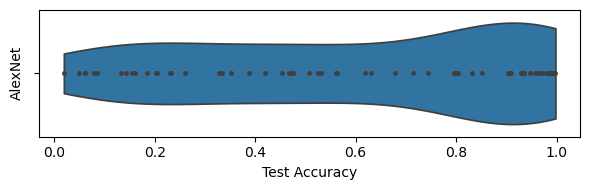

In [188]:
# Violin plot of test accuracies
plt.figure(figsize=(6, 2))
sns.violinplot(data=acc_alexnet_ad, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("AlexNet")
plt.tight_layout()
plt.savefig("figures/AlexNet_AD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [189]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in alexnet_ad["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [190]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred, pos_label=1)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.6218030931723878
F1 Score: 0.6990454463588881
Sensitivity: 0.8027853424799201
Specificity: 0.4031485569114156
ROC AUC: 0.6723416381634488
Confusion Matrix:
 [[ 9680 14331]
 [ 5721 23288]]


In [191]:
print(classification_report(all_y_true, all_y_pred, target_names=["CN", "AD"]))

              precision    recall  f1-score   support

          CN       0.63      0.40      0.49     24011
          AD       0.62      0.80      0.70     29009

    accuracy                           0.62     53020
   macro avg       0.62      0.60      0.60     53020
weighted avg       0.62      0.62      0.60     53020



In [192]:
# Subject-level predictions and true labels
rows = []

for fold in alexnet_ad["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]

    # Majority vote for subject-level prediction
    pred_majority = np.bincount(y_pred.astype(int)).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

subjects_alexnet_ad = pd.DataFrame(rows)
subjects_alexnet_ad.head()

,subject_id,true_label,pred_label
0,sub-001,1.0,1
1,sub-002,1.0,0
2,sub-003,1.0,0
3,sub-004,1.0,1
4,sub-005,1.0,1


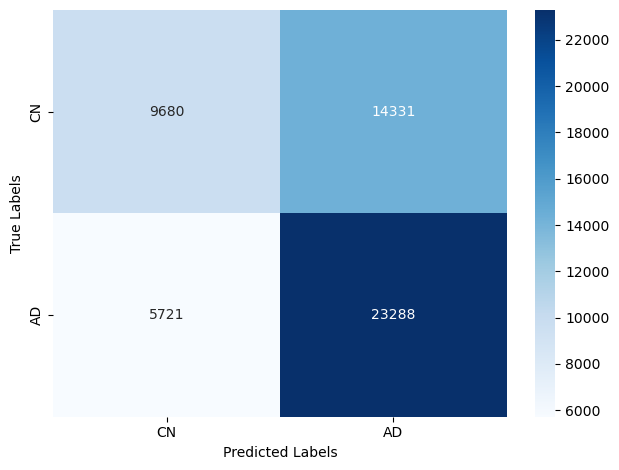

In [193]:
# Plot sample-level confusion matrix
class_names = ["CN", "AD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/AlexNet_AD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

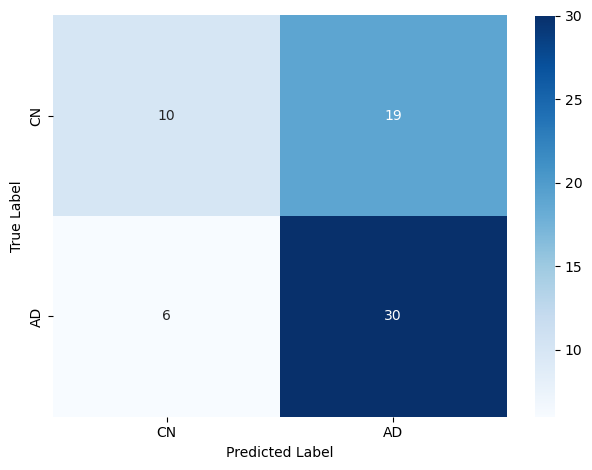

In [194]:
# Plot subject-level confusion matrix
cm_subjects = confusion_matrix(subjects_alexnet_ad["true_label"], subjects_alexnet_ad["pred_label"])
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/AlexNet_AD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

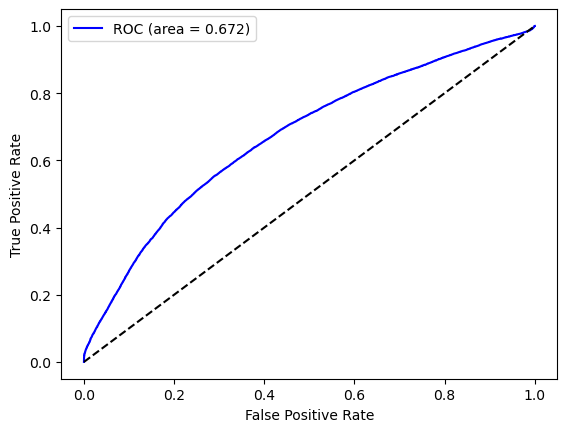

In [195]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/AlexNet_AD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

AlexNet FTD vs. CN Classification

In [196]:
# Load results from AlexNet FTD vs CN classification 
with open(os.path.join(RESULTS_DIR, "PretrainedAlexNet/alpha/C_F/all_results.pkl"), "rb") as f:
    alexnet_ftd = pickle.load(f)

In [197]:
# Check fold metadata
alexnet_ftd["meta_data"]

{'model_name': 'PretrainedAlexNet',
 'class_names': ['C', 'F'],
 'label_map': {'F': 1, 'C': 0},
 'band': 'alpha'}

In [198]:
# Append subject metadata to results
alexnet_ftd["subject_metadata"] = {}

for fold in alexnet_ftd["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        alexnet_ftd["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }
# Check updated metadata
alexnet_ftd["subject_metadata"]["sub-060"]

{'gender': 'F', 'age': np.int64(71), 'group': 'C'}

In [200]:
# Get the parameters of the best model based on validation accuracy
df_val_alexnet_ftd = pd.DataFrame(alexnet_ftd["outer_folds"])
best_row = df_val_alexnet_ftd.loc[df_val_alexnet_ftd["val_accuracy"].idxmax()]["best_params"]
best_model_path = df_val_alexnet_ftd.loc[df_val_alexnet_ftd["val_accuracy"].idxmax()]["model_filepath"]
for key, value in best_row.items():
    print(f"{key}: {value}")
print(best_model_path)
    

optimizer: Adam
learning_rate: 2.022059239644599e-05
weight_decay: 7.65372267501946e-06
batch_size: 128
alexnet_fc_units: 256
alexnet_fc_dropout: 0.36534896841802394
/home/u961155/thesis_codes/results/PretrainedAlexNet/alpha/C_F/best_model_outer_fold_29.pt


In [201]:
# Compile test accuracies by subject
test_accuracies = []

for fold in alexnet_ftd["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc,
    })

acc_alexnet_ftd = pd.DataFrame(test_accuracies)
acc_alexnet_ftd.head()

,test_subject_id,test_accuracy
0,sub-037,0.998708
1,sub-038,0.621622
2,sub-039,0.822904
3,sub-040,0.906445
4,sub-041,0.425821


In [202]:
print(acc_alexnet_ftd["test_accuracy"].mean(), acc_alexnet_ftd["test_accuracy"].std())

0.5838359572853034 0.3107661353089811


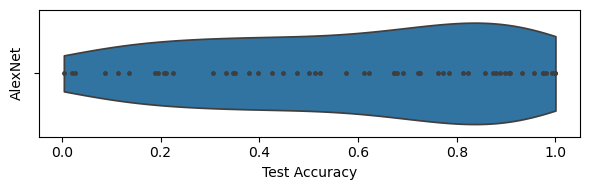

In [203]:
# Violin plot of test accuracies
plt.figure(figsize=(6, 2))
sns.violinplot(data=acc_alexnet_ftd, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("AlexNet")
plt.tight_layout()
plt.savefig("figures/AlexNet_FTD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [204]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in alexnet_ftd["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [205]:
print(classification_report(all_y_true, all_y_pred, target_names=["CN", "FTD"]))

              precision    recall  f1-score   support

          CN       0.64      0.72      0.68     24011
         FTD       0.50      0.40      0.45     16510

    accuracy                           0.59     40521
   macro avg       0.57      0.56      0.56     40521
weighted avg       0.58      0.59      0.58     40521



In [206]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.5929271242072012
F1 Score: 0.44760724691068615
Sensitivity: 0.40478497880072684
Specificity: 0.7222939486068886
ROC AUC: 0.5899523199555141
Confusion Matrix:
 [[17343  6668]
 [ 9827  6683]]


In [207]:
# Subject-level predictions and true labels
rows = []

for fold in alexnet_ftd["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]
    pred_majority = np.bincount(y_pred.astype(int)).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })
subjects_alexnet_ftd = pd.DataFrame(rows)
subjects_alexnet_ftd.head()

,subject_id,true_label,pred_label
0,sub-037,0.0,0
1,sub-038,0.0,0
2,sub-039,0.0,0
3,sub-040,0.0,0
4,sub-041,0.0,1


In [208]:
cm_subjects = confusion_matrix(subjects_alexnet_ftd["true_label"], subjects_alexnet_ftd["pred_label"])
print("Subject-level Confusion Matrix:\n", cm_subjects)

Subject-level Confusion Matrix:
 [[23  6]
 [14  9]]


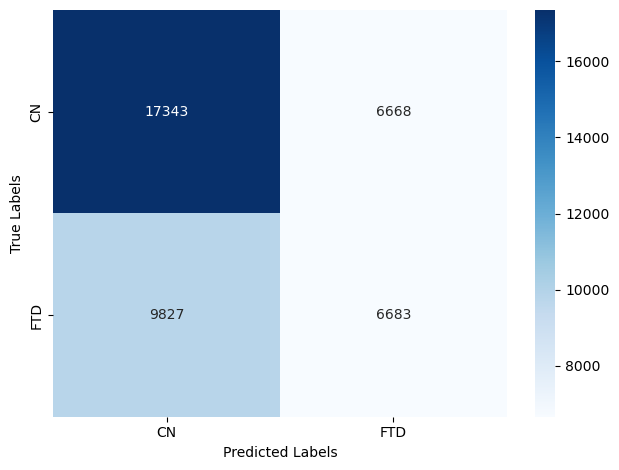

In [209]:
# Plot sample-level confusion matrix
class_names = ["CN", "FTD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/AlexNet_FTD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

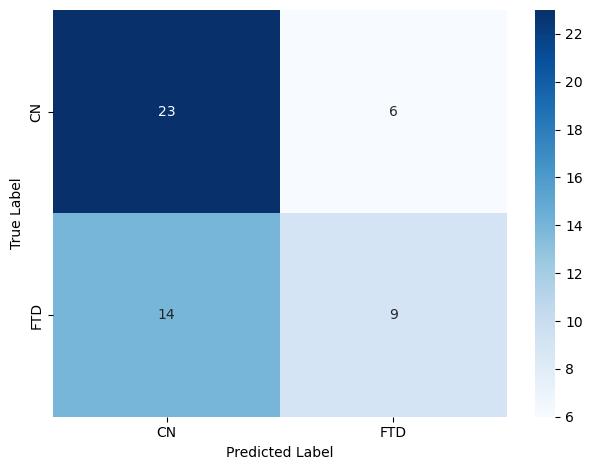

In [210]:
# Plot subject-level confusion matrix
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/AlexNet_FTD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

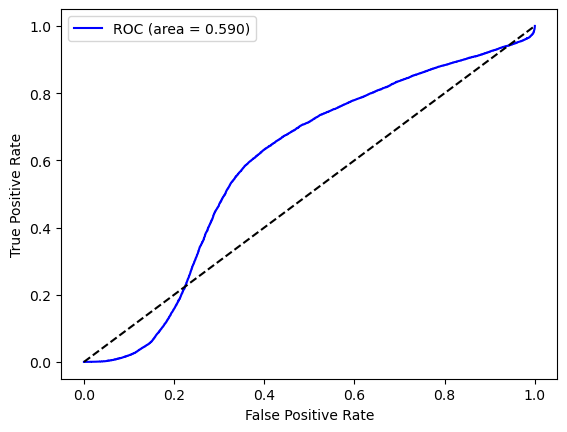

In [211]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/AlexNet_FTD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

ResNet AD vs. CN Classification

In [212]:
# Load results from ResNet AD vs CN classification
with open(os.path.join(RESULTS_DIR, "PretrainedResNet18/alpha/C_A/all_results.pkl"), "rb") as f:
    resnet_ad = pickle.load(f)

In [213]:
# Check fold metadata
resnet_ad["meta_data"]

{'model_name': 'PretrainedResNet18',
 'class_names': ['C', 'A'],
 'label_map': {'A': 1, 'C': 0},
 'band': 'alpha'}

In [214]:
# Check one fold results
fold_idx = 0
fold = resnet_ad["outer_folds"][fold_idx]

y_true = fold["true_labels"]
y_pred = fold["pred_labels"]
y_prob = fold["pred_probs"]

print("True labels:", y_true[:10])
print("Predicted labels:", y_pred[:10])
print("Predicted probabilities:", y_prob[:10])

True labels: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Predicted labels: [1. 1. 0. 1. 1. 1. 1. 1. 0. 1.]
Predicted probabilities: [0.53930175 0.66705596 0.4544375  0.60236996 0.5568721  0.6733773
 0.6411959  0.6630238  0.4801878  0.5860381 ]


In [215]:
# Append subject metadata to results
resnet_ad["subject_metadata"] = {}

for fold in resnet_ad["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        resnet_ad["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }

# Check updated metadata
resnet_ad["subject_metadata"]["sub-001"]

{'gender': 'F', 'age': np.int64(57), 'group': 'A'}

In [216]:
# Get the parameters of the best model based on validation accuracy
df_val_resnet_ad = pd.DataFrame(resnet_ad["outer_folds"])
best_row = df_val_resnet_ad.loc[df_val_resnet_ad["val_accuracy"].idxmax()]["best_params"]
best_model_path = df_val_resnet_ad.loc[df_val_resnet_ad["val_accuracy"].idxmax()]["model_filepath"]
for key, value in best_row.items():
    print(f"{key}: {value}")
print(best_model_path)

optimizer: AdamW
learning_rate: 1.6289035518021995e-05
weight_decay: 1.9482946128183935e-06
batch_size: 128
resnet_fc_units: 64
resnet_fc_dropout: 0.3544949579051435
/home/u961155/thesis_codes/results/PretrainedResNet18/alpha/C_A/best_model_outer_fold_18.pt


In [220]:
# Get test accuracies across folds
test_accuracies = []

for fold in resnet_ad["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc
    })

acc_resnet_ad = pd.DataFrame(test_accuracies)
acc_resnet_ad.head()

,test_subject_id,test_accuracy
0,sub-001,0.968121
1,sub-002,0.479747
2,sub-003,0.198020
3,sub-004,0.957326
4,sub-005,0.936330


In [221]:
print(acc_resnet_ad["test_accuracy"].mean(), acc_resnet_ad["test_accuracy"].std())

0.6416798941208981 0.29715621690739713


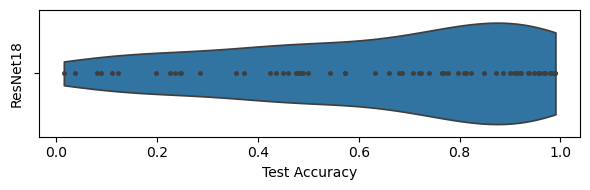

In [223]:
# Violin plot of test accuracies
plt.figure(figsize=(6, 2))
sns.violinplot(data=acc_resnet_ad, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("ResNet18")
plt.tight_layout()
plt.savefig("figures/ResNet18_AD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [224]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in resnet_ad["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [225]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred, pos_label=1)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.6507307169262004
F1 Score: 0.7171508787169028
Sensitivity: 0.7968906201523666
Specificity: 0.4679741379310345
ROC AUC: 0.6835845482258182
Confusion Matrix:
 [[10857 12343]
 [ 5892 23117]]


In [226]:
print(classification_report(all_y_true, all_y_pred, target_names=["CN", "AD"]))

              precision    recall  f1-score   support

          CN       0.65      0.47      0.54     23200
          AD       0.65      0.80      0.72     29009

    accuracy                           0.65     52209
   macro avg       0.65      0.63      0.63     52209
weighted avg       0.65      0.65      0.64     52209



In [227]:
# Plot subject-level confusion matrix
rows = []

for fold in resnet_ad["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]
    pred_majority = np.bincount(y_pred.astype(int)).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

subjects_resnet_ad = pd.DataFrame(rows)
subjects_resnet_ad.head()

,subject_id,true_label,pred_label
0,sub-001,1.0,1
1,sub-002,1.0,0
2,sub-003,1.0,0
3,sub-004,1.0,1
4,sub-005,1.0,1


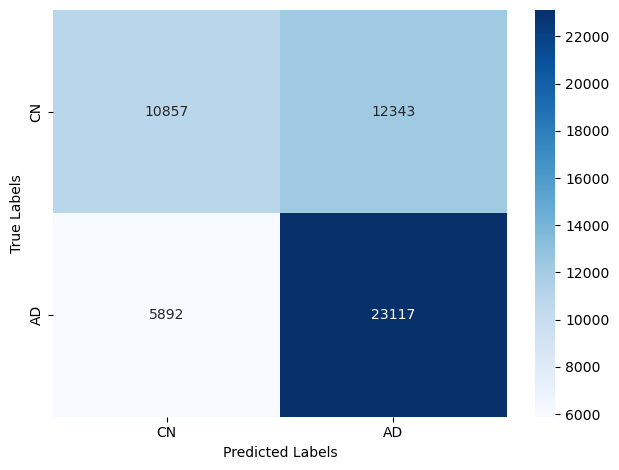

In [228]:
# Plot sample-level confusion matrix
class_names = ["CN", "AD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/ResNet18_AD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

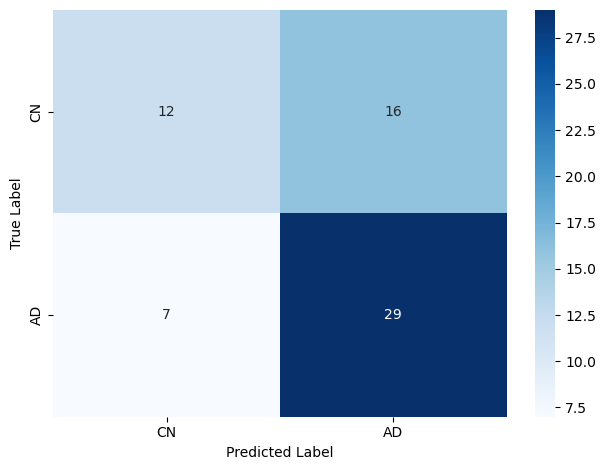

In [229]:
# Plot subject-level confusion matrix
cm_subjects = confusion_matrix(subjects_resnet_ad["true_label"], subjects_resnet_ad["pred_label"])
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/ResNet18_AD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

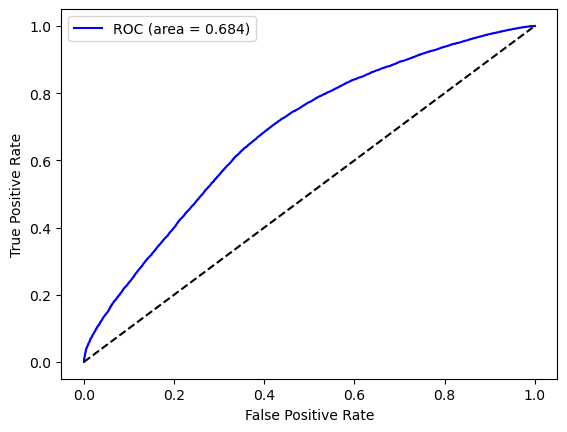

In [230]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/ResNet18_AD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

ResNet FTD vs. CN Classification

In [231]:
# Load results from ResNet FTD vs CN classification
with open(os.path.join(RESULTS_DIR, "PretrainedResNet18/alpha/C_F/all_results.pkl"), "rb") as f:
    resnet_ftd = pickle.load(f)

In [232]:
# Check fold metadata
resnet_ftd["meta_data"]

{'model_name': 'PretrainedResNet18',
 'class_names': ['C', 'F'],
 'label_map': {'F': 1, 'C': 0},
 'band': 'alpha'}

In [233]:
# Append subject metadata to results
resnet_ftd["subject_metadata"] = {}

for fold in resnet_ftd["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        resnet_ftd["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }
# Check updated metadata
resnet_ftd["subject_metadata"]["sub-060"]

{'gender': 'F', 'age': np.int64(71), 'group': 'C'}

In [234]:
# Get the parameters of the best model based on validation accuracy
df_val_resnet_ftd = pd.DataFrame(resnet_ftd["outer_folds"])
best_row = df_val_resnet_ftd.loc[df_val_resnet_ftd["val_accuracy"].idxmax()]["best_params"]
best_model_path = df_val_resnet_ftd.loc[df_val_resnet_ftd["val_accuracy"].idxmax()]["model_filepath"]
for key, value in best_row.items():
    print(f"{key}: {value}")
print(best_model_path)

optimizer: Adam
learning_rate: 1.115013849345786e-05
weight_decay: 5.355510823479652e-06
batch_size: 256
resnet_fc_units: 256
resnet_fc_dropout: 0.10812239313686567
/home/u961155/thesis_codes/results/PretrainedResNet18/alpha/C_F/best_model_outer_fold_37.pt


In [235]:
# Compile test accuracies by subject
test_accuracies = []

for fold in resnet_ftd["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc
    })

acc_resnet_ftd = pd.DataFrame(test_accuracies)
acc_resnet_ftd.head()

,test_subject_id,test_accuracy
0,sub-037,0.975452
1,sub-038,0.704955
2,sub-039,0.916175
3,sub-040,0.876299
4,sub-041,0.494904


In [236]:
print(acc_resnet_ftd["test_accuracy"].mean(), acc_resnet_ftd["test_accuracy"].std())

0.6008094464643643 0.279598777688375


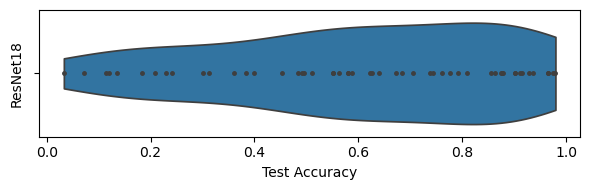

In [237]:
# Violin plot of test accuracies
plt.figure(figsize=(6, 2))
sns.violinplot(data=acc_resnet_ftd, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("ResNet18")
plt.tight_layout()
plt.savefig("figures/ResNet18_FTD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [238]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in resnet_ftd["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [239]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.6097085461859283
F1 Score: 0.47435769601489014
Sensitivity: 0.4322228952150212
Specificity: 0.731747948856774
ROC AUC: 0.6178578508875942
Confusion Matrix:
 [[17570  6441]
 [ 9374  7136]]


In [240]:
print(classification_report(all_y_true, all_y_pred, target_names=["CN", "FTD"]))

              precision    recall  f1-score   support

          CN       0.65      0.73      0.69     24011
         FTD       0.53      0.43      0.47     16510

    accuracy                           0.61     40521
   macro avg       0.59      0.58      0.58     40521
weighted avg       0.60      0.61      0.60     40521



In [241]:
# Subject-level predictions and true labels
rows = []

for fold in resnet_ftd["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]
    pred_majority = np.bincount(y_pred.astype(int)).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

subjects_resnet_ftd = pd.DataFrame(rows)
subjects_resnet_ftd.head()

,subject_id,true_label,pred_label
0,sub-037,0.0,0
1,sub-038,0.0,0
2,sub-039,0.0,0
3,sub-040,0.0,0
4,sub-041,0.0,1


In [242]:
cm_subjects = confusion_matrix(subjects_resnet_ftd["true_label"], subjects_resnet_ftd["pred_label"])
print("Subject-level Confusion Matrix:\n", cm_subjects)

Subject-level Confusion Matrix:
 [[23  6]
 [12 11]]


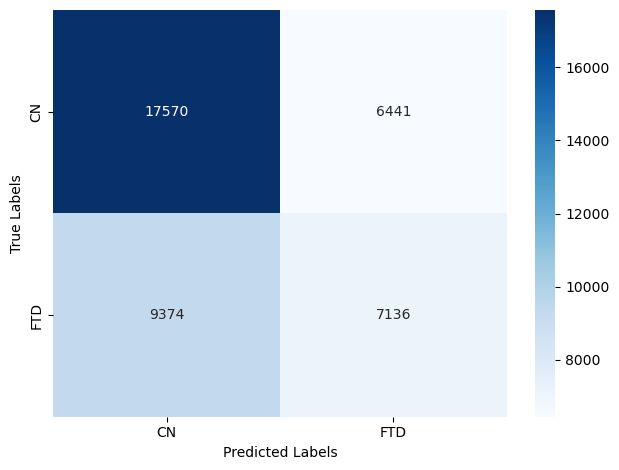

In [243]:
# Plot sample-level confusion matrix
class_names = ["CN", "FTD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/ResNet18_FTD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

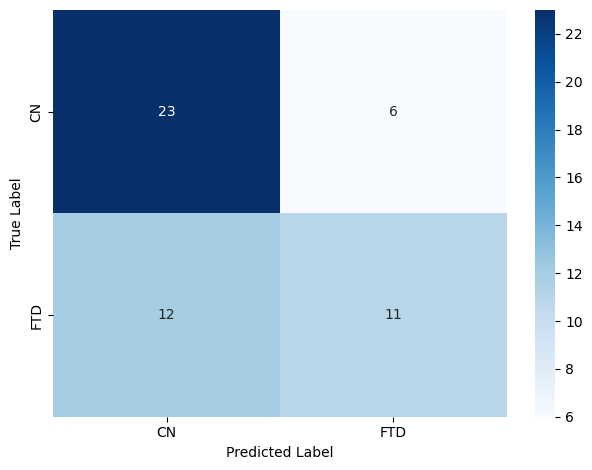

In [244]:
# Plot subject-level confusion matrix
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/ResNet18_FTD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

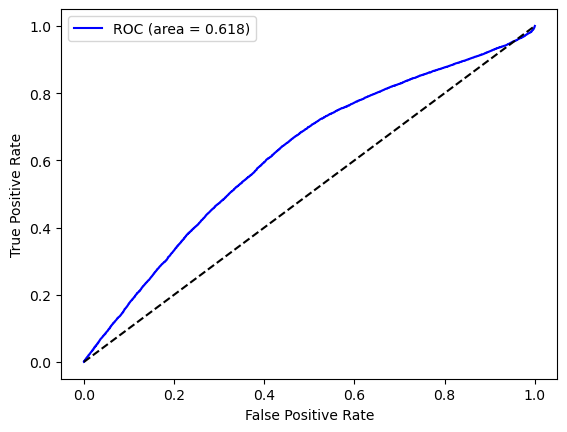

In [245]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/ResNet18_FTD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

VGG16 AD vs. CN classification

In [246]:
# Load results from VGG16 AD vs CN classification
with open(os.path.join(RESULTS_DIR, "PretrainedVGG16/alpha/C_A/all_results.pkl"), "rb") as f:
    vgg_ad = pickle.load(f)

In [247]:
# Check fold metadata
vgg_ad["meta_data"]

{'model_name': 'PretrainedVGG16',
 'class_names': ['C', 'A'],
 'label_map': {'A': 1, 'C': 0},
 'band': 'alpha'}

In [248]:
# Append subject metadata to results
vgg_ad["subject_metadata"] = {}

for fold in vgg_ad["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        vgg_ad["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }
# Check updated metadata
vgg_ad["subject_metadata"]["sub-001"]

{'gender': 'F', 'age': np.int64(57), 'group': 'A'}

In [249]:
# Get the best validation accuracy from VGG16 AD vs CN
df_val_vgg_ad = pd.DataFrame(vgg_ad["outer_folds"])
best_row = df_val_vgg_ad.loc[df_val_vgg_ad["val_accuracy"].idxmax()]["best_params"]
best_model_path = df_val_vgg_ad.loc[df_val_vgg_ad["val_accuracy"].idxmax()]["model_filepath"]
for key, value in best_row.items():
    print(f"{key}: {value}")
print(best_model_path)

optimizer: AdamW
learning_rate: 1.418930824305103e-05
weight_decay: 3.6591379354843304e-06
batch_size: 256
vgg_fc_units: 128
vgg_fc_dropout: 0.22688019171026422
/home/u961155/thesis_codes/results/PretrainedVGG16/alpha/C_A/best_model_outer_fold_31.pt


In [250]:
# Get test accuracies across folds
test_accuracies = []

for fold in vgg_ad["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc
    })

acc_vgg_ad = pd.DataFrame(test_accuracies)
acc_vgg_ad.head()

,test_subject_id,test_accuracy
0,sub-001,0.911074
1,sub-002,0.429114
2,sub-003,0.386139
3,sub-004,0.990043
4,sub-005,0.977528


In [251]:
print(acc_vgg_ad["test_accuracy"].mean(), acc_vgg_ad["test_accuracy"].std())

0.6755141278191541 0.2871780293549911


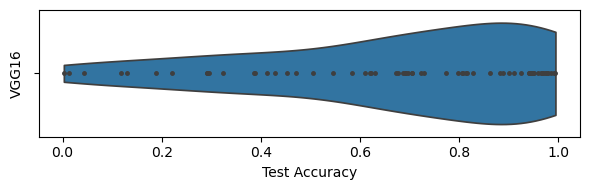

In [253]:
# Violin plot of test accuracies
plt.figure(figsize=(6, 2))
sns.violinplot(data=acc_vgg_ad, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("VGG16")
plt.tight_layout()
plt.savefig("figures/VGG16_AD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [254]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in vgg_ad["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [255]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.6793474160694077
F1 Score: 0.7266676313124005
Sensitivity: 0.7790340928677307
Specificity: 0.5589104993544626
ROC AUC: 0.712650191946752
Confusion Matrix:
 [[13420 10591]
 [ 6410 22599]]


In [256]:
print(classification_report(all_y_true, all_y_pred, target_names=["CN", "AD"]))

              precision    recall  f1-score   support

          CN       0.68      0.56      0.61     24011
          AD       0.68      0.78      0.73     29009

    accuracy                           0.68     53020
   macro avg       0.68      0.67      0.67     53020
weighted avg       0.68      0.68      0.67     53020



In [ ]:
# Subject-level predictions and true labels
rows = []

for fold in vgg_ad["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]
    pred_majority = np.bincount(y_pred.astype(int)).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

subjects_vgg_ad = pd.DataFrame(rows)
subjects_vgg_ad.head()

,subject_id,true_label,pred_label
0,sub-001,1.0,1
1,sub-002,1.0,0
2,sub-003,1.0,0
3,sub-004,1.0,1
4,sub-005,1.0,1


In [259]:
cm_subjects = confusion_matrix(subjects_vgg_ad["true_label"], subjects_vgg_ad["pred_label"])
print("Subject-level Confusion Matrix:\n", cm_subjects)

Subject-level Confusion Matrix:
 [[19 10]
 [ 7 29]]


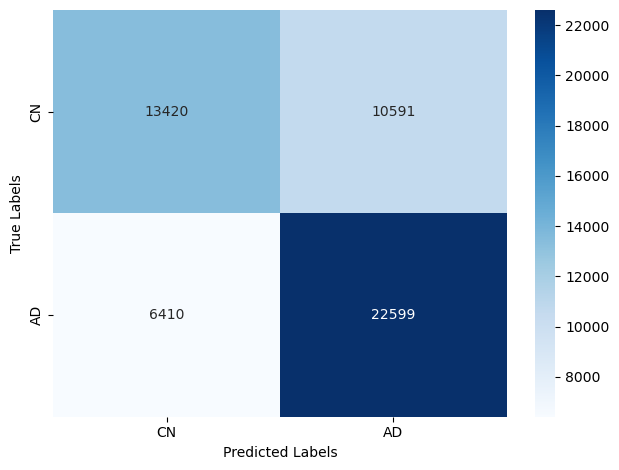

In [260]:
# Plot sample-level confusion matrix
class_names = ["CN", "AD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/VGG16_AD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

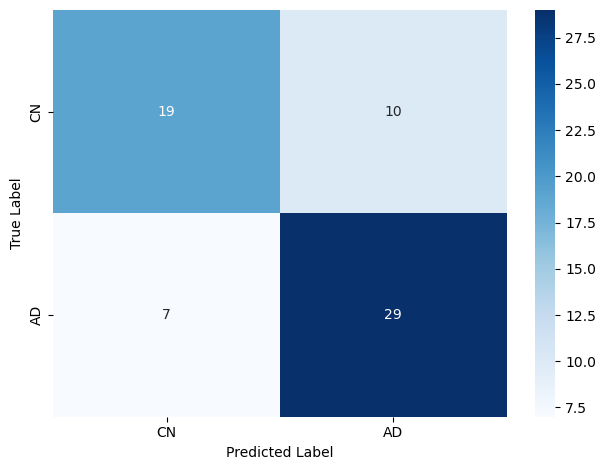

In [261]:
# Plot subject-level confusion matrix
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/VGG16_AD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

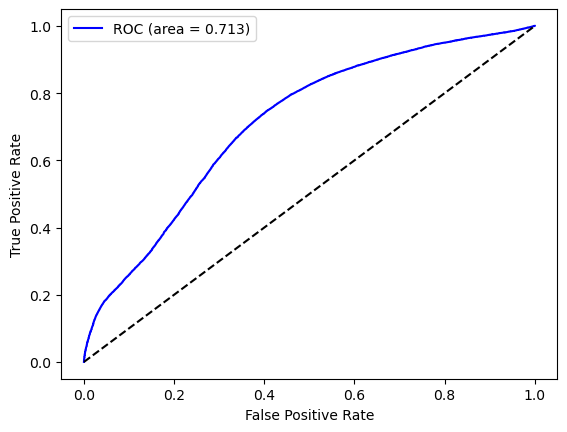

In [262]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/VGG16_AD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

VGG FTD vs. CN Classification

In [263]:
# Load results from VGG16 FTD vs CN classification
with open(os.path.join(RESULTS_DIR, "PretrainedVGG16/alpha/C_F/all_results.pkl"), "rb") as f:
    vgg_ftd = pickle.load(f)

In [264]:
# Check fold metadata
vgg_ftd["meta_data"]

{'model_name': 'PretrainedVGG16',
 'class_names': ['C', 'F'],
 'label_map': {'F': 1, 'C': 0},
 'band': 'alpha'}

In [265]:
# Append subject metadata to results
vgg_ftd["subject_metadata"] = {}

for fold in vgg_ftd["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        vgg_ftd["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }
# Check updated metadata
vgg_ftd["subject_metadata"]["sub-060"]

{'gender': 'F', 'age': np.int64(71), 'group': 'C'}

In [266]:
# Get the parameters of the best model based on validation accuracy
df_val_vgg_ftd = pd.DataFrame(vgg_ftd["outer_folds"])
best_row = df_val_vgg_ftd.loc[df_val_vgg_ftd["val_accuracy"].idxmax()]["best_params"]
best_model_path = df_val_vgg_ftd.loc[df_val_vgg_ftd["val_accuracy"].idxmax()]["model_filepath"]
for key, value in best_row.items():
    print(f"{key}: {value}")
print(best_model_path)

optimizer: Adam
learning_rate: 1.3951922985983938e-05
weight_decay: 1.9155873305091395e-05
batch_size: 128
vgg_fc_units: 128
vgg_fc_dropout: 0.29869746905394234
/home/u961155/thesis_codes/results/PretrainedVGG16/alpha/C_F/best_model_outer_fold_28.pt


In [267]:
# Compile test accuracies by subject
test_accuracies = []

for fold in vgg_ftd["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc
    })

acc_vgg_ftd = pd.DataFrame(test_accuracies)
acc_vgg_ftd.head()

,test_subject_id,test_accuracy
0,sub-037,0.990956
1,sub-038,0.709459
2,sub-039,0.819362
3,sub-040,0.793139
4,sub-041,0.456399


In [268]:
print(acc_vgg_ftd["test_accuracy"].mean(), acc_vgg_ftd["test_accuracy"].std())

0.5700115803360509 0.2969936864425137


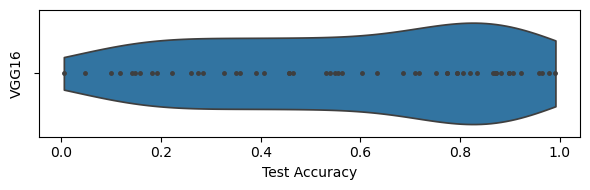

In [269]:
# Violin plot of test accuracies
plt.figure(figsize=(6, 2))
sns.violinplot(data=acc_vgg_ftd, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("VGG16")
plt.tight_layout()
plt.savefig("figures/VGG16_FTD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [270]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in vgg_ftd["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [271]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.5743688457836678
F1 Score: 0.44793700585768703
Sensitivity: 0.4238037552998183
Specificity: 0.6778976302528008
ROC AUC: 0.584107745791154
Confusion Matrix:
 [[16277  7734]
 [ 9513  6997]]


In [273]:
print(classification_report(all_y_true, all_y_pred, target_names=["CN", "FTD"]))

              precision    recall  f1-score   support

          CN       0.63      0.68      0.65     24011
         FTD       0.47      0.42      0.45     16510

    accuracy                           0.57     40521
   macro avg       0.55      0.55      0.55     40521
weighted avg       0.57      0.57      0.57     40521



In [274]:
# Subject-level predictions and true labels
rows = []

for fold in vgg_ftd["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]

    # Majority vote for subject-level prediction
    pred_majority = np.bincount(y_pred.astype(int)).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

subjects_vgg_ftd = pd.DataFrame(rows)
subjects_vgg_ftd.head()

,subject_id,true_label,pred_label
0,sub-037,0.0,0
1,sub-038,0.0,0
2,sub-039,0.0,0
3,sub-040,0.0,0
4,sub-041,0.0,1


In [275]:
cm_subjects = confusion_matrix(subjects_vgg_ftd["true_label"], subjects_vgg_ftd["pred_label"])
print("Subject-level Confusion Matrix:\n", cm_subjects)

Subject-level Confusion Matrix:
 [[22  7]
 [14  9]]


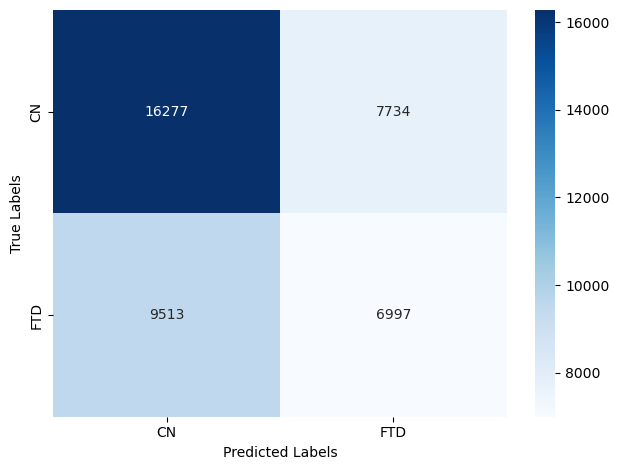

In [276]:
# Plot sample-level confusion matrix
class_names = ["CN", "FTD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",  
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/VGG16_FTD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

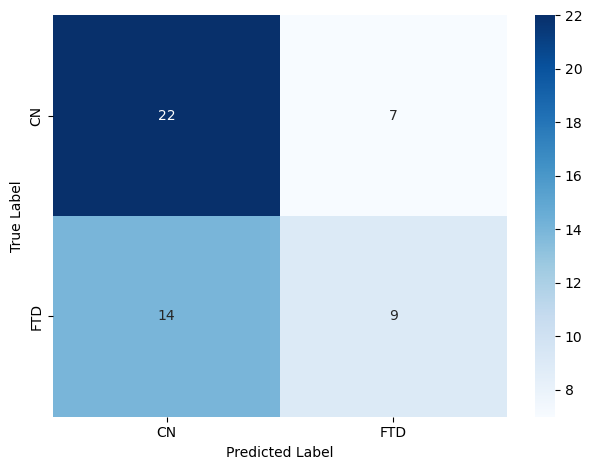

In [277]:
# Plot subject-level confusion matrix
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/VGG16_FTD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

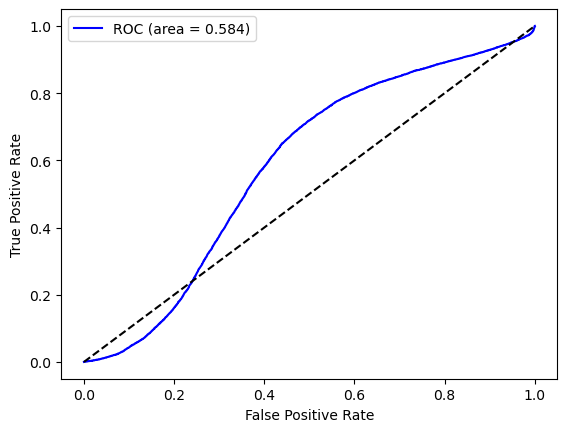

In [278]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/VGG16_FTD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()